In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# Load Data
df = pd.read_csv("C:\\Users\\hande\\Downloads\\tmdb_top_10k_movies_2026.csv.csv")

# Clean column names
df.columns = df.columns.str.lower()

df.head()

,unnamed: 0,genre_ids,id,original_language,overview,popularity,release_date,title,vote_average,vote_count
0,0,"[18, 80]",278,en,Imprisoned in the 1940s for the double murder ...,30.8191,1994-09-23,The Shawshank Redemption,8.716,29721
1,1,"[18, 80]",238,en,"Spanning the years 1945 to 1955, a chronicle o...",36.4215,1972-03-14,The Godfather,8.687,22451
2,2,"[18, 80]",240,en,In the continuing saga of the Corleone crime f...,17.5941,1974-12-20,The Godfather Part II,8.571,13586
3,3,"[18, 36, 10752]",424,en,The true story of how businessman Oskar Schind...,18.6937,1993-12-15,Schindler's List,8.567,17106
4,4,[18],389,en,The defense and the prosecution have rested an...,13.0084,1957-04-10,12 Angry Men,8.555,9741


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   unnamed: 0         10000 non-null  int64  
 1   genre_ids          10000 non-null  object 
 2   id                 10000 non-null  int64  
 3   original_language  10000 non-null  object 
 4   overview           9998 non-null   object 
 5   popularity         10000 non-null  float64
 6   release_date       9997 non-null   object 
 7   title              10000 non-null  object 
 8   vote_average       10000 non-null  float64
 9   vote_count         10000 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 781.4+ KB


,unnamed: 0,id,popularity,vote_average,vote_count
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,4999.50000,2.252508e+05,4.280559,6.729167,2077.979600
std,2886.89568,2.991634e+05,7.960604,0.660076,3318.455958
min,0.00000,2.000000e+00,0.003200,5.400000,300.000000
25%,2499.75000,1.032975e+04,1.776575,6.212750,473.000000
50%,4999.50000,4.162000e+04,2.855200,6.700000,868.000000
75%,7499.25000,4.033328e+05,4.874800,7.208000,2077.250000
max,9999.00000,1.472638e+06,340.838100,8.716000,38859.000000


In [4]:
# Check Missing Values
df.isnull().sum()

unnamed: 0           0
genre_ids            0
id                   0
original_language    0
overview             2
popularity           0
release_date         3
title                0
vote_average         0
vote_count           0
dtype: int64

# 📊 EDA (Exploratory Data Analysis)

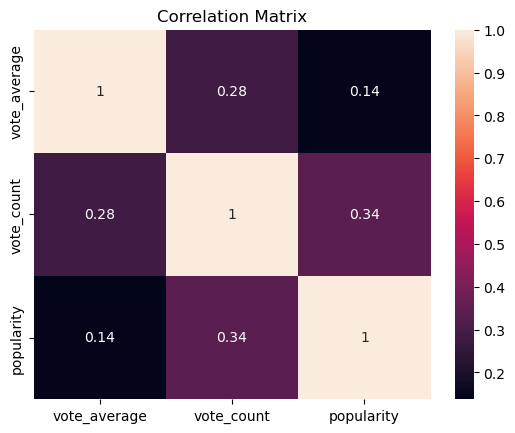

In [7]:
# Correlation
corr = df[["vote_average", "vote_count", "popularity"]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

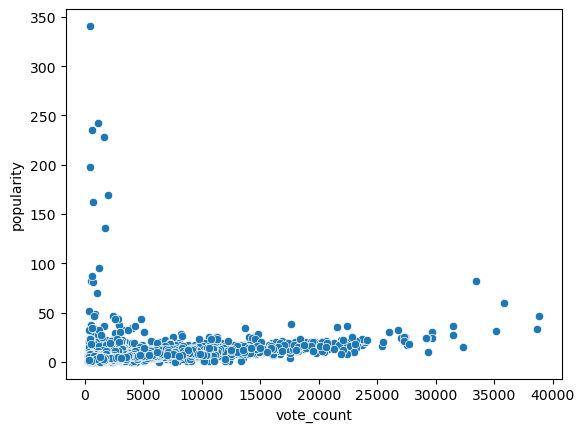

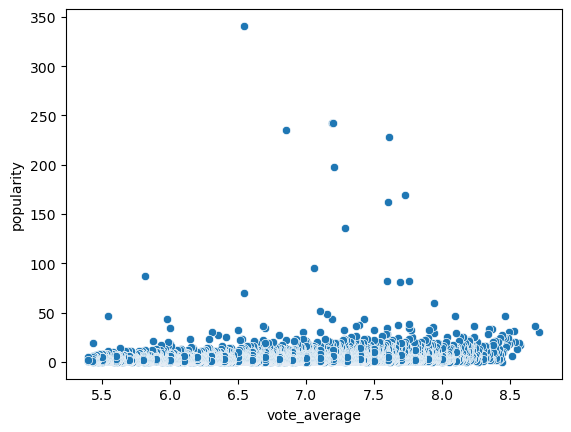

In [8]:
# Scatter Plots
plt.figure()
sns.scatterplot(x=df["vote_count"], y=df["popularity"])
plt.show()

plt.figure()
sns.scatterplot(x=df["vote_average"], y=df["popularity"])
plt.show()

# ⚙️ Preprocessing

In [9]:
 # Select Features 
df = df[["vote_average", "vote_count", "popularity"]].dropna()

In [10]:
# Feature Engineering 
df["score"] = df["vote_average"] * df["vote_count"]

In [11]:
# Split
X = df.drop("popularity", axis=1)
y = df["popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🤖 Model Training (Multiple Algorithms)

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

In [14]:
# Train All Models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=50),
    "GradientBoost": GradientBoostingRegressor(),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=50),
    "KNN": KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results[name] = r2

    print(f"{name} → R2: {r2:.4f}, RMSE: {rmse:.2f}")

Linear → R2: 0.1652, RMSE: 6.94
Ridge → R2: 0.1652, RMSE: 6.94
Lasso → R2: 0.1377, RMSE: 7.05
DecisionTree → R2: -0.3419, RMSE: 8.80
RandomForest → R2: -0.0634, RMSE: 7.83
GradientBoost → R2: 0.0920, RMSE: 7.24
ExtraTrees → R2: -0.0640, RMSE: 7.83
KNN → R2: 0.0867, RMSE: 7.26


In [15]:
# Best Model
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: Ridge


# 🔥 Model Optimization (VERY IMPORTANT)

In [16]:
# Hyperparameter Tuning (RandomForest)
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10]
}

rf = RandomForestRegressor()

grid = GridSearchCV(rf, param_grid, cv=3, scoring="r2")
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 5, 'n_estimators': 50}


In [17]:
# Final Evaluation
pred = best_model.predict(X_test_scaled)

print("Final R2:", r2_score(y_test, pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

Final R2: 0.12439703742493624
Final RMSE: 7.105804197392136


In [18]:
# SAVE FILES
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model & Scaler saved")

✅ Model & Scaler saved


In [ ]:
pip install numpy scikit-learn pandas joblib --upgrade